# Corporate Credit Portfolio Risk Analytics

## 1. Portfolio Construction

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

companies = [
    ("Suncor Energy", "Energy", "Canada"),
    ("Canadian Natural Resources", "Energy", "Canada"),
    ("Cenovus Energy", "Energy", "Canada"),
    ("Enbridge", "Energy", "Canada"),
    ("Exxon Mobil", "Energy", "United States"),
    ("Chevron", "Energy", "United States"),

    ("Brookfield", "Real Estate / Infrastructure", "Canada"),
    ("American Tower", "Real Estate / Infrastructure", "United States"),
    ("Prologis", "Real Estate / Infrastructure", "United States"),

    ("Canadian National Railway", "Industrials", "Canada"),
    ("Canadian Pacific Kansas City", "Industrials", "Canada"),
    ("Caterpillar", "Industrials", "United States"),
    ("Honeywell", "Industrials", "United States"),

    ("Fortis", "Utilities", "Canada"),
    ("Emera", "Utilities", "Canada"),
    ("American Electric Power", "Utilities", "United States"),

    ("BCE", "Telecom", "Canada"),
    ("TELUS", "Telecom", "Canada"),
    ("Verizon", "Telecom", "United States"),

    ("Loblaw", "Consumer", "Canada"),
    ("Walmart", "Consumer", "United States"),
    ("Costco", "Consumer", "United States"),

    ("Air Canada", "Transportation", "Canada"),
    ("Delta Air Lines", "Transportation", "United States"),
    ("UPS", "Transportation", "United States"),

    ("Microsoft", "Technology", "United States"),
    ("Oracle", "Technology", "United States"),
    ("Shopify", "Technology", "Canada"),
    ("Salesforce", "Technology", "United States"),
    ("Apple", "Technology", "United States"),
]

df = pd.DataFrame(companies, columns=["borrower_name", "sector_group", "country"])

df["borrower_id"] = range(1, len(df) + 1)

df["revenue"] = np.random.uniform(5_000_000_000, 250_000_000_000, len(df))
df["ebitda_margin"] = np.random.uniform(0.12, 0.38, len(df))
df["ebitda"] = df["revenue"] * df["ebitda_margin"]
df["total_debt"] = df["ebitda"] * np.random.uniform(1.0, 5.5, len(df))
df["interest_expense"] = df["total_debt"] * np.random.uniform(0.035, 0.075, len(df))

df["debt_to_ebitda"] = df["total_debt"] / df["ebitda"]
df["interest_coverage"] = df["ebitda"] / df["interest_expense"]

df.head()

,borrower_name,sector_group,country,borrower_id,revenue,ebitda_margin,ebitda,total_debt,interest_expense,debt_to_ebitda,interest_coverage
0,Suncor Energy,Energy,Canada,1,9.676233e+10,0.277962,2.689622e+10,7.393899e+10,2.941572e+09,2.749048,9.143485
1,Canadian Natural Resources,Energy,Canada,2,2.379250e+11,0.164336,3.909971e+10,8.684321e+10,5.517131e+09,2.221071,7.086964
2,Cenovus Energy,Energy,Canada,3,1.843385e+11,0.136913,2.523842e+10,1.193605e+11,7.809926e+09,4.729319,3.231582
3,Enbridge,Energy,Canada,4,1.516713e+11,0.366710,5.561943e+10,1.449103e+11,8.325255e+09,2.605390,6.680808
4,Exxon Mobil,Energy,United States,5,4.322457e+10,0.371064,1.603909e+10,3.631580e+10,2.390985e+09,2.264205,6.708154


## 2. Credit Risk Layer
### 2.1 Internal Rating Assignment
### 2.2 Probability of Default Mapping
### 2.3 Expected Loss Calculation

In [4]:
np.random.seed(42)

facility_types = ["Revolver", "Term Loan", "Syndicated Loan"]

df["facility_type"] = np.random.choice(
    facility_types,
    size=len(df),
    p=[0.35, 0.45, 0.20]
)

df["ead"] = np.random.uniform(
    50_000_000,
    750_000_000,
    len(df)
)

df["lgd"] = np.random.uniform(
    0.25,
    0.60,
    len(df)
)

internal_rating = []

for i in range(len(df)):
    if (df["debt_to_ebitda"][i] < 2.0) & (df["interest_coverage"][i] > 8):
        rating = 'A'
    elif (df["debt_to_ebitda"][i] < 3.5) & (df["interest_coverage"][i] > 4):
        rating = 'BBB'
    elif (df["debt_to_ebitda"][i] < 5.0) & (df["interest_coverage"][i] > 2):
        rating = 'BB'
    else: 
        rating = 'B'
    internal_rating.append(rating)
    
df['internal_rating']=internal_rating

  
pd_map = []

for i in df['internal_rating']:
    if i == 'A':
        pd = 0.003
    elif i == 'BBB':
        pd = 0.010
    elif i == 'BB':
        pd = 0.035
    else:
        pd = 0.075
    pd_map.append(pd)

df['pd']=pd_map


df["expected_loss"] = df["pd"] * df["lgd"] * df["ead"]

df[[
    "borrower_name",
    "sector_group",
    "facility_type",
    "ead",
    "internal_rating",
    "pd",
    "lgd",
    "expected_loss"
]].iloc[-15:,:]

,borrower_name,sector_group,facility_type,ead,internal_rating,pd,lgd,expected_loss
15,American Electric Power,Utilities,Revolver,5.137656e+08,BB,0.035,0.505153,9.083549e+06
16,BCE,Telecom,Revolver,2.681978e+08,BB,0.035,0.519945,4.880679e+06
17,TELUS,Telecom,Term Loan,4.140476e+08,A,0.003,0.275916,3.427266e+05
18,Verizon,Telecom,Term Loan,4.326972e+08,BBB,0.010,0.375463,1.624618e+06
19,Loblaw,Consumer,Revolver,1.793981e+08,A,0.003,0.290554,1.563746e+05
20,Walmart,Consumer,Term Loan,7.287092e+08,BB,0.035,0.552086,1.408086e+07
21,Costco,Consumer,Revolver,5.925930e+08,BB,0.035,0.468154,9.709874e+06
22,Air Canada,Transportation,Revolver,7.076493e+08,BBB,0.010,0.365814,2.588682e+06
23,Delta Air Lines,Transportation,Term Loan,6.763791e+08,A,0.003,0.272245,5.524234e+05
24,UPS,Transportation,Term Loan,4.685300e+08,BBB,0.010,0.358844,1.681291e+06


## 3. Regulatory Capital, Pricing & RAROC Proxy
### 3.1 Risk Weights and RWA
### 3.2 Regulatory Capital
### 3.3 Loan Pricing
### 3.4 Risk-Adjusted Return and RAROC Proxy

In [6]:
# building the: regulatory capital layer, pricing layer and RAROC layer.
risk_weight = []

for i in df['internal_rating']:
    if i == 'A':
        rwa_map = 0.5
    elif i == 'BBB':
        rwa_map = 0.75
    elif i == 'BB':
        rwa_map = 1.0
    else:
        rwa_map = 1.5
        
    risk_weight.append(rwa_map)
        
df['risk_weight']=risk_weight


In [7]:
# $RWA = EAD * RWA%
df['RWA']= df['risk_weight']*df['ead']
df[['risk_weight','ead','RWA']].head()

,risk_weight,ead,RWA
0,0.75,4.752814e+08,3.564610e+08
1,0.75,1.693669e+08,1.270252e+08
2,1.00,9.553612e+07,9.553612e+07
3,0.75,7.142199e+08,5.356649e+08
4,0.75,7.259424e+08,5.444568e+08


In [8]:
# $ Capital requirement = 8% * $RWA 
# Capital Adequacy Ratio = 8% under Basel III
df['regulatory_capital']=0.08*df['RWA']

In [9]:
# Pricing layer
# Assigning interest rates based on rating quality
loan_rate = []
for i in df['internal_rating']:
    if i == 'A':
        rate = 0.045
    elif i == 'BBB':
        rate = 0.055
    elif i == 'BB':
        rate = 0.075
    else:
        rate = 0.11
    loan_rate.append(rate)

df['loan_rate']=loan_rate

In [10]:
#Loan Revenue = loan rate% * EAD
df['loan_revenue']=df['loan_rate']*df['ead']

#RAROC = risk-adjusted returns / economic capital
#Since we haven't yet modeled Unexpected Loss distribution & VaR 99.9%, we assume economic capital = regulatory capital for now.
df['risk_adjusted_returns']=df['loan_revenue']-df['expected_loss']
df['RAROC']=df['risk_adjusted_returns']/df['regulatory_capital']


In [11]:
df = df.rename(columns ={'RWA':'rwa', 'RAROC':'raroc'})

## 4. Portfolio Aggregation & Concentration Risk
### 4.1 Executive Portfolio Metrics
### 4.2 Sector Concentration Analysis

In [13]:
print('Executive Portfolio Metrics')

total_exposure = df['loan_revenue'].sum().round(2)
print("Total Exposure: $",total_exposure)

total_expected_loss=df['expected_loss'].sum().round(2)
print('Total Expected Loss: $',total_expected_loss)

total_rwa=df['rwa'].sum().round(2)
print('Total RWA: $',total_rwa)

total_regulatory_capital=df['regulatory_capital'].sum().round(2)
print('Total Regulatory Capital: $', total_regulatory_capital)

average_pd=df['pd'].mean()
print(f'Average PD:{average_pd:.2%}')

average_lgd=df['lgd'].mean()
print(f'Average LGD: {average_lgd:.2%}')

portfolio_raroc_proxy = df['raroc'].mean()
print(f'Portfolio RAROC: {portfolio_raroc_proxy:.2%}')

Executive Portfolio Metrics
Total Exposure: $ 725236885.61
Total Expected Loss: $ 105862759.55
Total RWA: $ 9516534161.93
Total Regulatory Capital: $ 761322732.95
Average PD:2.05%
Average LGD: 41.88%
Portfolio RAROC: 84.47%


In [14]:
sector_summary = (
    df.groupby("sector_group")
    .agg(
        total_exposure=("ead", "sum"),
        total_expected_loss=("expected_loss", "sum"),
        total_rwa=("rwa", "sum"),
        total_regulatory_capital=("regulatory_capital", "sum"),
        average_pd=("pd", "mean"),
        average_lgd=("lgd", "mean")
    )
    .reset_index()
)

sector_summary["exposure_pct"] = sector_summary["total_exposure"] / total_exposure

sector_summary = sector_summary.sort_values(
    by="total_exposure",
    ascending=False
)

sector_summary

,sector_group,total_exposure,total_expected_loss,total_rwa,total_regulatory_capital,average_pd,average_lgd,exposure_pct
1,Energy,2.796225e+09,1.214038e+07,2.121053e+09,1.696842e+08,0.014167,0.405700,3.855602
6,Transportation,1.852558e+09,4.822396e+06,1.220324e+09,9.762592e+07,0.007667,0.332301,2.554418
0,Consumer,1.500700e+09,2.394711e+07,1.411001e+09,1.128801e+08,0.024333,0.436932,2.069255
7,Utilities,1.431436e+09,2.597263e+07,1.431436e+09,1.145149e+08,0.035000,0.512655,1.973749
4,Technology,1.353835e+09,1.036490e+07,1.110574e+09,8.884594e+07,0.025000,0.463624,1.866749
5,Telecom,1.114943e+09,6.848024e+06,7.997445e+08,6.397956e+07,0.016000,0.390441,1.537350
2,Industrials,9.642293e+08,1.889387e+07,9.079348e+08,7.263478e+07,0.029000,0.421795,1.329537
3,Real Estate / Infrastructure,9.105632e+08,2.873459e+06,5.144669e+08,4.115735e+07,0.013667,0.368728,1.255539


### 4.3 Geography Concentration Analysis

In [16]:
import pandas as pd 
pd.options.display.max_columns=None
df.head()

,borrower_name,sector_group,country,borrower_id,revenue,ebitda_margin,ebitda,total_debt,interest_expense,debt_to_ebitda,interest_coverage,facility_type,ead,lgd,internal_rating,pd,expected_loss,risk_weight,rwa,regulatory_capital,loan_rate,loan_revenue,risk_adjusted_returns,raroc
0,Suncor Energy,Energy,Canada,1,9.676233e+10,0.277962,2.689622e+10,7.393899e+10,2.941572e+09,2.749048,9.143485,Term Loan,4.752814e+08,0.386037,BBB,0.010,1.834762e+06,0.75,3.564610e+08,2.851688e+07,0.055,2.614048e+07,2.430571e+07,0.852327
1,Canadian Natural Resources,Energy,Canada,2,2.379250e+11,0.164336,3.909971e+10,8.684321e+10,5.517131e+09,2.221071,7.086964,Syndicated Loan,1.693669e+08,0.344972,BBB,0.010,5.842686e+05,0.75,1.270252e+08,1.016201e+07,0.055,9.315179e+06,8.730910e+06,0.859171
2,Cenovus Energy,Energy,Canada,3,1.843385e+11,0.136913,2.523842e+10,1.193605e+11,7.809926e+09,4.729319,3.231582,Term Loan,9.553612e+07,0.540058,BB,0.035,1.805827e+06,1.00,9.553612e+07,7.642889e+06,0.075,7.165209e+06,5.359382e+06,0.701225
3,Enbridge,Energy,Canada,4,1.516713e+11,0.366710,5.561943e+10,1.449103e+11,8.325255e+09,2.605390,6.680808,Term Loan,7.142199e+08,0.374864,BBB,0.010,2.677351e+06,0.75,5.356649e+08,4.285319e+07,0.055,3.928209e+07,3.660474e+07,0.854189
4,Exxon Mobil,Energy,United States,5,4.322457e+10,0.371064,1.603909e+10,3.631580e+10,2.390985e+09,2.264205,6.708154,Revolver,7.259424e+08,0.348327,BBB,0.010,2.528654e+06,0.75,5.444568e+08,4.355655e+07,0.055,3.992683e+07,3.739818e+07,0.858612


In [17]:
country_segment = (
df.groupby('country').agg(
    total_exposure=('loan_revenue','sum'),
    total_expected_loss=('expected_loss','sum'),
    total_rwa=('rwa','sum'),
    average_pd=('pd','mean'),
    average_lgd=('lgd','mean')
)
)
country_segment.reset_index()
country_segment.sort_values(by='total_exposure', ascending = False)
country_segment['exposure_pct']= country_segment['total_exposure']/country_segment['total_exposure'].sum()

country_segment


,total_exposure,total_expected_loss,total_rwa,average_pd,average_lgd,exposure_pct
country,,,,,,
Canada,3.119020e+08,5.355363e+07,4.119405e+09,0.023857,0.429938,0.430069
United States,4.133349e+08,5.230913e+07,5.397129e+09,0.017625,0.408971,0.569931


### 4.4 Rating Bucket Analysis

In [19]:
rating_segment=(
    df.groupby('internal_rating').
    agg(
        total_exposure=('ead','sum'),
        total_expected_loss=('expected_loss','sum'),
        total_rwa=('rwa','sum'),
        average_pd=('pd','mean'),
        average_lgd=('lgd','mean')   
    )  
)  


rating_segment.reset_index() 
rating_segment['borrower_count']= df.groupby('internal_rating')['borrower_id'].sum()

rating_segment

,total_exposure,total_expected_loss,total_rwa,average_pd,average_lgd,borrower_count
internal_rating,,,,,,
A,2.532713e+09,2.162233e+06,1.266357e+09,0.003,0.283659,103
B,3.581067e+08,1.599154e+07,5.371601e+08,0.075,0.595410,10
BB,3.751061e+09,6.779685e+07,3.751061e+09,0.035,0.517358,211
BBB,5.282608e+09,1.991214e+07,3.961956e+09,0.010,0.377335,141


In [20]:
### 4.5 Top Single-Name Exposures

In [21]:
# The goal is to minimize single name concentration risk in our portfolio 
top_single_name_exposure=df.sort_values(by='ead').iloc[-5:,:]
top_single_name_exposure=top_single_name_exposure[['borrower_name','borrower_id','sector_group','country','internal_rating','ead','expected_loss','rwa']]
top_single_name_exposure.set_index('ead')

,borrower_name,borrower_id,sector_group,country,internal_rating,expected_loss,rwa
ead,,,,,,,
6.953120e+08,Microsoft,26,Technology,United States,BBB,2.529643e+06,5.214840e+08
7.076493e+08,Air Canada,23,Transportation,Canada,BBB,2.588682e+06,5.307369e+08
7.142199e+08,Enbridge,4,Energy,Canada,BBB,2.677351e+06,5.356649e+08
7.259424e+08,Exxon Mobil,5,Energy,United States,BBB,2.528654e+06,5.444568e+08
7.287092e+08,Walmart,21,Consumer,United States,BB,1.408086e+07,7.287092e+08


## 5. Rating Migration Analysis
### 5.1 Prior Rating Generation

In [23]:
prior_rating = []

for i in df['internal_rating']:
    if i == 'A':
        selected_prior_rating=np.random.choice(['A','BBB'])
    elif i == 'BBB':
        selected_prior_rating=np.random.choice(['A','BBB','BB'])
    elif i == 'BB':
        selected_prior_rating=np.random.choice(['BBB','BB','B'])
    else:
        selected_prior_rating=np.random.choice(['B','BB'])
        
    prior_rating.append(selected_prior_rating)  

df['prior_rating']=prior_rating

df[['prior_rating','internal_rating']]

,prior_rating,internal_rating
0,A,BBB
1,BB,BBB
2,BB,BB
3,BB,BBB
4,A,BBB
5,A,BBB
6,BBB,A
7,B,BB
8,A,A
9,BB,B


## 5.2 Migration Status

In [25]:
migration_analysis=[]

for i in range(len(df)):
    if (df['prior_rating'][i]=='A') & (df['internal_rating'][i]=='A'):
        output='Unchanged'
    elif (df['prior_rating'][i]=='A') & (df['internal_rating'][i]=='BBB'):
        output='Downgrade'
    elif (df['prior_rating'][i]=='BBB') & (df['internal_rating'][i]=='BBB'):
        output='Unchanged'
    elif (df['prior_rating'][i]=='BBB') & (df['internal_rating'][i]=='A'):
        output='Upgrade'
    elif (df['prior_rating'][i]=='BBB') & (df['internal_rating'][i]=='BB'):  
        output='Downgrade'
    elif (df['prior_rating'][i]=='BB') & (df['internal_rating'][i]=='BBB'):
        output='Upgrade'
    elif (df['prior_rating'][i]=='BB') & (df['internal_rating'][i]=='BB'):
        output='Unchanged'
    elif (df['prior_rating'][i]=='BB') & (df['internal_rating'][i]=='B'):
        output='Downgrade'
    elif (df['prior_rating'][i]=='B') & (df['internal_rating'][i]=='BB'):
        output='Upgrade'
    elif (df['prior_rating'][i]=='B') & (df['internal_rating'][i]=='B'):
        output='Unchanged'
        
    migration_analysis.append(output)
    
df['migration_analysis']=migration_analysis
df[['migration_analysis','prior_rating','internal_rating']]

,migration_analysis,prior_rating,internal_rating
0,Downgrade,A,BBB
1,Upgrade,BB,BBB
2,Unchanged,BB,BB
3,Upgrade,BB,BBB
4,Downgrade,A,BBB
5,Downgrade,A,BBB
6,Upgrade,BBB,A
7,Upgrade,B,BB
8,Unchanged,A,A
9,Downgrade,BB,B


## 5.3 Rating Transition Matrix

In [27]:
rating_transition_matrix = pd.crosstab(
    df['prior_rating'],df['internal_rating']
)
rating_transition_matrix

internal_rating,A,B,BB,BBB
prior_rating,,,,
A,4,0,0,7
B,0,0,8,0
BB,0,1,3,2
BBB,3,0,1,1


## 5.4 Migration Summary

In [29]:
migration_summary=df.groupby('migration_analysis').agg(
    borrower_count=('borrower_id','count'),
    total_exposure=('ead','sum'),
    total_expected_loss=('expected_loss','sum'),
    total_rwa=('rwa','sum'),
    average_pd=('pd','mean'),
    average_lgd=('lgd','mean')
)
migration_summary=migration_summary.reset_index()
migration_summary['migration_exposure_pct']=df['ead']/df['ead'].sum()
migration_summary

,migration_analysis,borrower_count,total_exposure,total_expected_loss,total_rwa,average_pd,average_lgd,migration_exposure_pct
0,Downgrade,9,4.173761e+09,3.209245e+07,3.426887e+09,0.020000,0.421164,0.039858
1,Unchanged,8,2.751868e+09,1.933041e+07,1.988512e+09,0.015875,0.383387,0.014203
2,Upgrade,13,4.998860e+09,5.443990e+07,4.101135e+09,0.023769,0.438854,0.008012


## 6. Stress Testing Framework

### 6.1 Stressed Probability of Default

In [32]:
df['sector_group'].unique()

array(['Energy', 'Real Estate / Infrastructure', 'Industrials',
       'Utilities', 'Telecom', 'Consumer', 'Transportation', 'Technology'],
      dtype=object)

In [33]:
# Stressed PDs occur in times of recession where PD increases and  defaults cluster together
# We're essentially representing the right tail of the credit loss distribution

stress_category=[]

for i in df['sector_group']:
    if i == 'Energy':
        multiplier=2
    elif i =='Real Estate / Infrastructure':
        mulitplier=1.8
    elif i == 'Industrials':
        multiplier=1.5
    elif i == 'Utilities':
        multiplier=1.1
    elif i =='Telecom':
        multiplier=1.15
    elif i =='Consumer':
        multiplier=1.3
    elif i =='Transportation':
        multiplier=1.6
    else:
        multiplier=1.25
    stress_category.append(multiplier)

df['stress_multiplier']=stress_category
df['stressed_pd']=df['pd']*df['stress_multiplier']

### 6.2 Stressed Expected Loss

In [35]:
df['stressed_expected_loss']=df['stressed_pd']*df['ead']*df['lgd']

### 6.3 Stress Capital Impact

In [37]:
# Even though the % Capital Adequacy Ratio remains the same (8% Basel III) regardless of economic conditions, 
# Revew why RWA is before capital stress

df['stressed_rwa']=df['rwa']*1.2
df['stressed_regulatory_capital']=0.08*df['stressed_rwa']

# 7. Correlation & Systemic Portfolio Risk

## 7.1 Sector Correlation Matrix

In [39]:
# Assumption-based correlation modeling

sectors = [
    "Energy",
    "Real Estate / Infrastructure",
    "Industrials",
    "Utilities",
    "Telecom",
    "Consumer",
    "Transportation",
    "Technology"
]

sector_correlation_matrix = pd.DataFrame(
    [
        [1.00, 0.65, 0.70, 0.30, 0.35, 0.50, 0.60, 0.45],
        [0.65, 1.00, 0.55, 0.40, 0.35, 0.55, 0.45, 0.40],
        [0.70, 0.55, 1.00, 0.35, 0.40, 0.60, 0.65, 0.50],
        [0.30, 0.40, 0.35, 1.00, 0.45, 0.30, 0.25, 0.25],
        [0.35, 0.35, 0.40, 0.45, 1.00, 0.35, 0.30, 0.40],
        [0.50, 0.55, 0.60, 0.30, 0.35, 1.00, 0.55, 0.45],
        [0.60, 0.45, 0.65, 0.25, 0.30, 0.55, 1.00, 0.45],
        [0.45, 0.40, 0.50, 0.25, 0.40, 0.45, 0.45, 1.00],
    ],
    index=sectors,
    columns=sectors
)

sector_correlation_matrix

,Energy,Real Estate / Infrastructure,Industrials,Utilities,Telecom,Consumer,Transportation,Technology
Energy,1.00,0.65,0.70,0.30,0.35,0.50,0.60,0.45
Real Estate / Infrastructure,0.65,1.00,0.55,0.40,0.35,0.55,0.45,0.40
Industrials,0.70,0.55,1.00,0.35,0.40,0.60,0.65,0.50
Utilities,0.30,0.40,0.35,1.00,0.45,0.30,0.25,0.25
Telecom,0.35,0.35,0.40,0.45,1.00,0.35,0.30,0.40
Consumer,0.50,0.55,0.60,0.30,0.35,1.00,0.55,0.45
Transportation,0.60,0.45,0.65,0.25,0.30,0.55,1.00,0.45
Technology,0.45,0.40,0.50,0.25,0.40,0.45,0.45,1.00


## 7.2 Correlated Portfolio Risk Interpretation

In [41]:
correlation_risk_interpretation = pd.DataFrame({
    "portfolio_type": [
        "Low correlation / diversified",
        "High correlation / concentrated"
    ],
    "default_behavior": [
        "Borrower defaults are more independent",
        "Borrowers deteriorate together during stress"
    ],
    "diversification_effect": [
        "Strong diversification benefit",
        "Weak diversification benefit"
    ],
    "tail_risk_impact": [
        "Lower tail losses",
        "Higher tail losses / fatter right tail"
    ],
    "economic_capital_impact": [
        "Lower economic capital requirement",
        "Higher economic capital requirement"
    ]
})

correlation_risk_interpretation

,portfolio_type,default_behavior,diversification_effect,tail_risk_impact,economic_capital_impact
0,Low correlation / diversified,Borrower defaults are more independent,Strong diversification benefit,Lower tail losses,Lower economic capital requirement
1,High correlation / concentrated,Borrowers deteriorate together during stress,Weak diversification benefit,Higher tail losses / fatter right tail,Higher economic capital requirement


## 8. Monte CarloPortfolio Simulation
### 8.1 Simulated Default Generation

In [43]:
n_simulations=1000
simulated_losses = []

for simulation in range(n_simulations):

    portfolio_loss = 0

    for i in range(len(df)):

        random_draw = np.random.random()

        if random_draw < df["pd"][i]:
            default = 1
        else:
            default = 0

        borrower_loss = default * df["lgd"][i] * df["ead"][i]

        portfolio_loss += borrower_loss

    simulated_losses.append(portfolio_loss)

### 8.2 Loss Given Default Calculation

In [45]:
df['pd'].describe()

count    30.000000
mean      0.020533
std       0.017360
min       0.003000
25%       0.010000
50%       0.010000
75%       0.035000
max       0.075000
Name: pd, dtype: float64

### 8.3 Portfolio Loss Per Simulation

In [47]:
simulated_losses=pd.DataFrame(simulated_losses)
simulated_losses.columns = ['portfolio_loss']
simulated_losses.describe()

# Simulated Expected Loss = 110.9M
# Std = 160.9M, losses are highly volatile. It represents tail risk, heavy uncertainty, unstable outcomes.
# Median (50%) = 0: more than half the simulations produced no defaults.
# Distribution of portolio losses is positively skewed (right-skewed): most observation on the left with smaller losses and tail risk on the right, few extreme losses.

,portfolio_loss
count,1.000000e+03
mean,1.110119e+08
std,1.608801e+08
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,2.132205e+08
max,1.029413e+09


### 8.4 Portfolio Loss Distribution

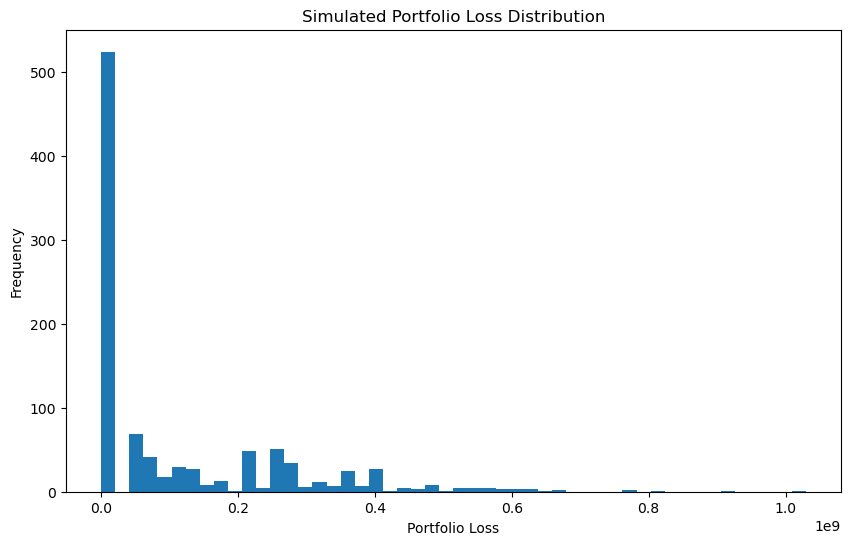

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(simulated_losses['portfolio_loss'], bins=50)

plt.xlabel('Portfolio Loss')
plt.ylabel('Frequency')
plt.title('Simulated Portfolio Loss Distribution')

plt.show()

### 8.5 Expected Shortfall (ES) - Understanding Extreme Tail Risk 

In [51]:
var_99= np.percentile(simulated_losses,99)
var_99

626570785.7450689

In [52]:
var_99 = simulated_losses['portfolio_loss'].quantile(0.99)

print("99% VaR:", var_99)

99% VaR: 626570785.7450689


In [53]:
expected_shortfall = simulated_losses['portfolio_loss'][simulated_losses['portfolio_loss']>= var_99].mean()
print("Expected Shortfall i.e. Average Extreme Tail Portfolio Losses: $",expected_shortfall)

Expected Shortfall i.e. Average Extreme Tail Portfolio Losses: $ 752616097.7434717


# 9 Economic Capital


In [55]:
# Economic Capital

expected_loss_mc = simulated_losses[
    "portfolio_loss"
].mean()

economic_capital = (
    var_99 -
    expected_loss_mc
)

print(
    "Expected Loss:",
    round(expected_loss_mc,2)
)

print(
    "Economic Capital:",
    round(economic_capital,2)
)

Expected Loss: 111011864.16
Economic Capital: 515558921.58


## 9.1 Executive Risk Metrics

In [57]:
economic_capital_summary = pd.DataFrame({

    "Metric":[
        "Expected Loss",
        "VaR 99%",
        "Expected Shortfall",
        "Economic Capital"
    ],

    "Value":[
        expected_loss_mc,
        var_99,
        expected_shortfall,
        economic_capital
    ]
})

economic_capital_summary

,Metric,Value
0,Expected Loss,1.110119e+08
1,VaR 99%,6.265708e+08
2,Expected Shortfall,7.526161e+08
3,Economic Capital,5.155589e+08


# 10. True RAROC

In [59]:
# Currently, the RAROC proxy is = returns / regulatory capital
# The true RAROC includes Economic Capital as the denominator 

In [60]:
portfolio_revenue = df[
    "loan_revenue"
].sum()

portfolio_expected_loss = df[
    "expected_loss"
].sum()

risk_adjusted_return = (
    portfolio_revenue -
    portfolio_expected_loss
)

true_raroc = (
    risk_adjusted_return /
    economic_capital
)

print(
    "True Portfolio RAROC:",
    round(true_raroc,4)
)

True Portfolio RAROC: 1.2014


# 11. Portfolio Optimization 

In [62]:
sector_weights = (df.groupby('sector_group')['ead'].sum())
sector_weights = sector_weights/sector_weights.sum()
sector_weights

sector_group
Consumer                        0.125850
Energy                          0.234494
Industrials                     0.080861
Real Estate / Infrastructure    0.076361
Technology                      0.113534
Telecom                         0.093500
Transportation                  0.155357
Utilities                       0.120042
Name: ead, dtype: float64

In [63]:
# Creation of hypotehetical target weigths to optimize our portfolio's RAROC & concentration risk  

In [64]:
optimized_portfolio = pd.DataFrame({
    "sector_group": sector_weights.index,
    "current_weight": sector_weights.values
})

In [65]:
optimized_portfolio['optimized_weight']=[
    0.13,
    0.15,
    0.10,
    0.10,
    0.15,
    0.10,
    0.12,
    0.15
]

optimized_portfolio

,sector_group,current_weight,optimized_weight
0,Consumer,0.125850,0.13
1,Energy,0.234494,0.15
2,Industrials,0.080861,0.10
3,Real Estate / Infrastructure,0.076361,0.10
4,Technology,0.113534,0.15
5,Telecom,0.093500,0.10
6,Transportation,0.155357,0.12
7,Utilities,0.120042,0.15


In [66]:
# Merge optimized weights into borrower-level portfolio
df_optimized = df.merge(
    optimized_portfolio,
    on="sector_group",
    how="left"
)

# Keep total portfolio exposure unchanged
total_ead = df["ead"].sum()

# Calculate current sector EAD
sector_current_ead = (
    df.groupby("sector_group")["ead"]
    .sum()
    .rename("current_sector_ead")
    .reset_index()
)

df_optimized = df_optimized.merge(
    sector_current_ead,
    on="sector_group",
    how="left"
)

# Target sector EAD based on optimized weights
df_optimized["target_sector_ead"] = (
    df_optimized["optimized_weight"] * total_ead
)

# Scale each loan's EAD within its sector
df_optimized["optimized_ead"] = (
    df_optimized["ead"]
    / df_optimized["current_sector_ead"]
    * df_optimized["target_sector_ead"]
)

# Recalculate expected loss
df_optimized["optimized_expected_loss"] = (
    df_optimized["pd"]
    * df_optimized["lgd"]
    * df_optimized["optimized_ead"]
)

df_optimized[[
    "sector_group",
    "ead",
    "optimized_ead",
    "expected_loss",
    "optimized_expected_loss"
]].head()

,sector_group,ead,optimized_ead,expected_loss,optimized_expected_loss
0,Energy,4.752814e+08,3.040253e+08,1.834762e+06,1.173650e+06
1,Energy,1.693669e+08,1.083397e+08,5.842686e+05,3.737417e+05
2,Energy,9.553612e+07,6.111201e+07,1.805827e+06,1.155141e+06
3,Energy,7.142199e+08,4.568682e+08,2.677351e+06,1.712633e+06
4,Energy,7.259424e+08,4.643668e+08,2.528654e+06,1.617515e+06


In [67]:
optimized_portfolio = pd.DataFrame({
    "sector":[
        "Consumer",                      
        "Energy",                      
        "Industrials",                   
        "Real Estate / Infrastructure",   
        "Technology",                    
        "Telecom",                        
        "Transportation",               
        "Utilities"
    ],
    "current_weight":[
        0.125850,
        0.234494,
        0.080861,
        0.076361,
        0.113534,
        0.093500,
        0.155357,
        0.120042
    ],
    "optimized_weight":[
        0.13,
        0.15,
        0.10,
        0.10,
        0.15,
        0.10,
        0.12,
        0.15
    ]
})
        
    

In [68]:
optimized_expected_loss = df_optimized["optimized_expected_loss"].sum()

optimized_revenue = (
    df_optimized["loan_revenue"]
    / df_optimized["ead"]
    * df_optimized["optimized_ead"]
).sum()

optimized_expected_loss, optimized_revenue

(116828863.1804684, 739045109.8592271)

In [69]:
optimized_portfolio = pd.DataFrame({

    "sector":[
        "Energy",
        "Real Estate / Infrastructure",
        "Industrials",
        "Utilities",
        "Telecom",
        "Consumer",
        "Transportation",
        "Technology"
    ],

    "current_weight":[
        0.22,
        0.16,
        0.18,
        0.08,
        0.10,
        0.10,
        0.08,
        0.08
    ],

    "optimized_weight":[
        0.15,
        0.12,
        0.18,
        0.10,
        0.10,
        0.12,
        0.10,
        0.13
    ]
})

optimized_portfolio

,sector,current_weight,optimized_weight
0,Energy,0.22,0.15
1,Real Estate / Infrastructure,0.16,0.12
2,Industrials,0.18,0.18
3,Utilities,0.08,0.10
4,Telecom,0.10,0.10
5,Consumer,0.10,0.12
6,Transportation,0.08,0.10
7,Technology,0.08,0.13


In [70]:
# Rerun of Monte Carlo with optimized EAD 

n_simulations = 50000

optimized_losses = []

for i in range(n_simulations):
    
    defaults = np.random.rand(len(df_optimized)) < df_optimized["pd"]
    
    loss = (
        defaults
        * df_optimized["optimized_ead"]
        * df_optimized["lgd"]
    ).sum()
    
    optimized_losses.append(loss)

optimized_losses = np.array(optimized_losses)

In [71]:
optimized_var_99 = np.percentile(optimized_losses, 99)

optimized_expected_shortfall = optimized_losses[
    optimized_losses >= optimized_var_99
].mean()

optimized_economic_capital = (
    optimized_var_99
    - optimized_expected_loss
)

optimized_raroc = (
    optimized_revenue
    - optimized_expected_loss
) / optimized_economic_capital

In [75]:
expected_loss = df["expected_loss"].sum()

In [77]:
portfolio_comparison = pd.DataFrame({

    "Metric": [
        "Expected Loss",
        "VaR 99%",
        "Expected Shortfall",
        "Economic Capital",
        "RAROC"
    ],

    "Current": [
        expected_loss,
        var_99,
        expected_shortfall,
        economic_capital,
        true_raroc
    ],

    "Optimized": [
        optimized_expected_loss,
        optimized_var_99,
        optimized_expected_shortfall,
        optimized_economic_capital,
        optimized_raroc
    ]
})

portfolio_comparison

,Metric,Current,Optimized
0,Expected Loss,1.058628e+08,1.168289e+08
1,VaR 99%,6.265708e+08,7.229935e+08
2,Expected Shortfall,7.526161e+08,8.319334e+08
3,Economic Capital,5.155589e+08,6.061646e+08
4,RAROC,1.201364e+00,1.026481e+00


## Portfolio Optimization Results

The initial optimization strategy focused exclusively on reducing sector concentration. However, the resulting portfolio exhibited higher Expected Loss, VaR, Expected Shortfall, and Economic Capital.

This outcome highlights an important portfolio management principle:

Diversification alone does not guarantee lower credit risk.

Although sector concentrations were reduced, the reallocation increased exposure to sectors containing borrowers with higher average default probabilities and loss severities.

Consequently, the analysis demonstrates that effective portfolio optimization must jointly consider:

Concentration risk
Borrower credit quality
Economic Capital
Risk-adjusted return

rather than relying solely on diversification objective

In [73]:
pd.options.display.max_columns=None
df

,borrower_name,sector_group,country,borrower_id,revenue,ebitda_margin,ebitda,total_debt,interest_expense,debt_to_ebitda,interest_coverage,facility_type,ead,lgd,internal_rating,pd,expected_loss,risk_weight,rwa,regulatory_capital,loan_rate,loan_revenue,risk_adjusted_returns,raroc,prior_rating,migration_analysis,stress_multiplier,stressed_pd,stressed_expected_loss,stressed_rwa,stressed_regulatory_capital
0,Suncor Energy,Energy,Canada,1,9.676233e+10,0.277962,2.689622e+10,7.393899e+10,2.941572e+09,2.749048,9.143485,Term Loan,4.752814e+08,0.386037,BBB,0.010,1.834762e+06,0.75,3.564610e+08,2.851688e+07,0.055,2.614048e+07,2.430571e+07,0.852327,A,Downgrade,2.00,0.02000,3.669525e+06,4.277533e+08,3.422026e+07
1,Canadian Natural Resources,Energy,Canada,2,2.379250e+11,0.164336,3.909971e+10,8.684321e+10,5.517131e+09,2.221071,7.086964,Syndicated Loan,1.693669e+08,0.344972,BBB,0.010,5.842686e+05,0.75,1.270252e+08,1.016201e+07,0.055,9.315179e+06,8.730910e+06,0.859171,BB,Upgrade,2.00,0.02000,1.168537e+06,1.524302e+08,1.219442e+07
2,Cenovus Energy,Energy,Canada,3,1.843385e+11,0.136913,2.523842e+10,1.193605e+11,7.809926e+09,4.729319,3.231582,Term Loan,9.553612e+07,0.540058,BB,0.035,1.805827e+06,1.00,9.553612e+07,7.642889e+06,0.075,7.165209e+06,5.359382e+06,0.701225,BB,Unchanged,2.00,0.07000,3.611654e+06,1.146433e+08,9.171467e+06
3,Enbridge,Energy,Canada,4,1.516713e+11,0.366710,5.561943e+10,1.449103e+11,8.325255e+09,2.605390,6.680808,Term Loan,7.142199e+08,0.374864,BBB,0.010,2.677351e+06,0.75,5.356649e+08,4.285319e+07,0.055,3.928209e+07,3.660474e+07,0.854189,BB,Upgrade,2.00,0.02000,5.354702e+06,6.427979e+08,5.142383e+07
4,Exxon Mobil,Energy,United States,5,4.322457e+10,0.371064,1.603909e+10,3.631580e+10,2.390985e+09,2.264205,6.708154,Revolver,7.259424e+08,0.348327,BBB,0.010,2.528654e+06,0.75,5.444568e+08,4.355655e+07,0.055,3.992683e+07,3.739818e+07,0.858612,A,Downgrade,2.00,0.02000,5.057308e+06,6.533482e+08,5.226785e+07
5,Chevron,Energy,United States,6,4.321866e+10,0.330183,1.427008e+10,4.911950e+10,2.689382e+09,3.442132,5.306081,Revolver,6.158781e+08,0.439944,BBB,0.010,2.709517e+06,0.75,4.619086e+08,3.695269e+07,0.055,3.387330e+07,3.116378e+07,0.843343,A,Downgrade,2.00,0.02000,5.419033e+06,5.542903e+08,4.434323e+07
6,Brookfield,Real Estate / Infrastructure,Canada,7,1.923048e+10,0.199200,3.830705e+09,6.259980e+09,3.499912e+08,1.634159,10.945145,Revolver,2.632296e+08,0.299323,A,0.003,2.363724e+05,0.50,1.316148e+08,1.052919e+07,0.045,1.184533e+07,1.160896e+07,1.102551,BBB,Upgrade,2.00,0.00600,4.727449e+05,1.579378e+08,1.263502e+07
7,American Tower,Real Estate / Infrastructure,United States,8,2.172132e+11,0.145395,3.158165e+10,1.455878e+11,7.585365e+09,4.609886,4.163498,Syndicated Loan,1.183705e+08,0.530769,BB,0.035,2.198958e+06,1.00,1.183705e+08,9.469638e+06,0.075,8.877786e+06,6.678828e+06,0.705289,B,Upgrade,2.00,0.07000,4.397916e+06,1.420446e+08,1.136357e+07
8,Prologis,Real Estate / Infrastructure,United States,9,1.522732e+11,0.297901,4.536227e+10,6.058031e+10,2.181907e+09,1.335478,20.790196,Term Loan,5.289631e+08,0.276093,A,0.003,4.381286e+05,0.50,2.644816e+08,2.115852e+07,0.045,2.380334e+07,2.336521e+07,1.104293,A,Unchanged,2.00,0.00600,8.762572e+05,3.173779e+08,2.539023e+07
9,Canadian National Railway,Industrials,Canada,10,1.784778e+11,0.234440,4.184227e+10,2.276634e+11,8.950737e+09,5.440991,4.674729,Term Loan,3.581067e+08,0.595410,B,0.075,1.599154e+07,1.50,5.371601e+08,4.297281e+07,0.110,3.939174e+07,2.340021e+07,0.544535,BB,Downgrade,1.50,0.11250,2.398731e+07,6.445921e+08,5.156737e+07
